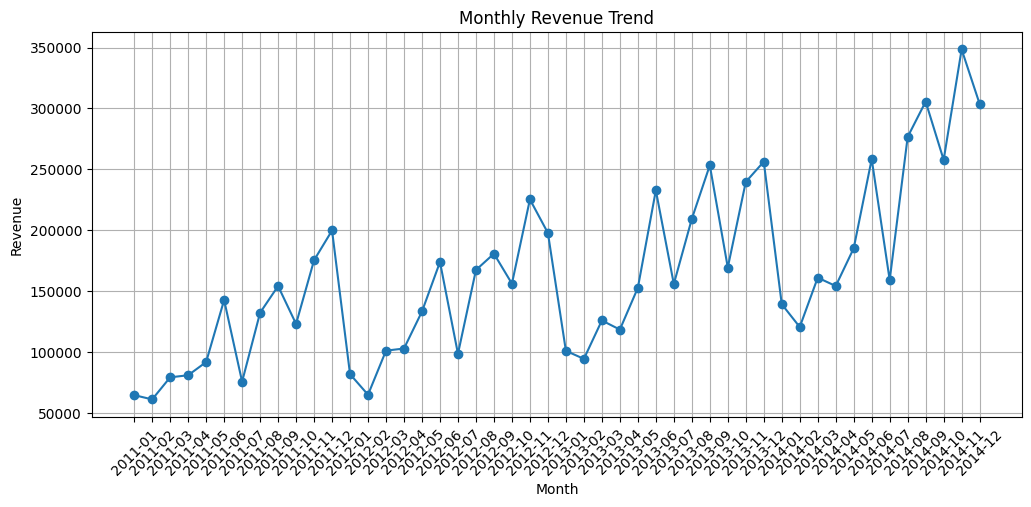

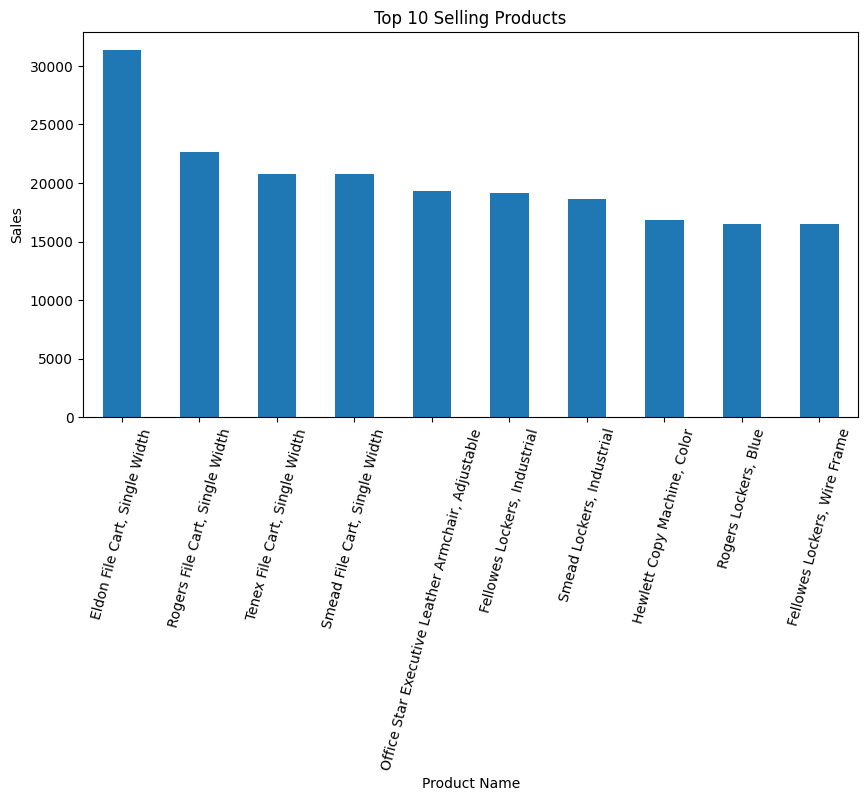

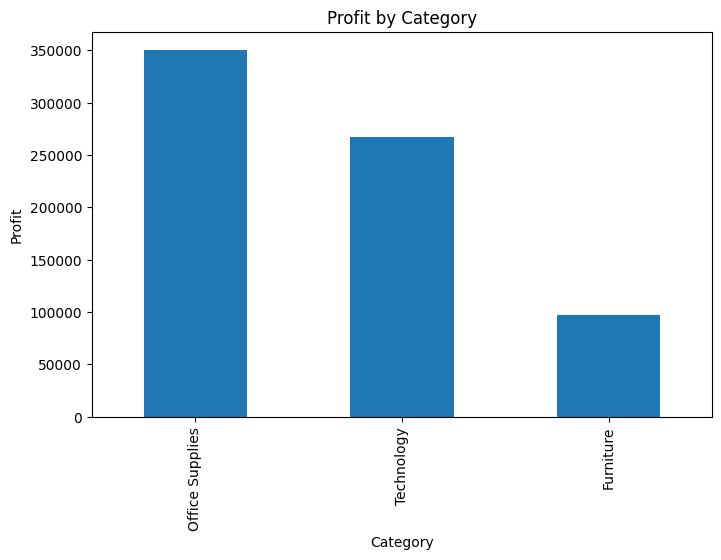

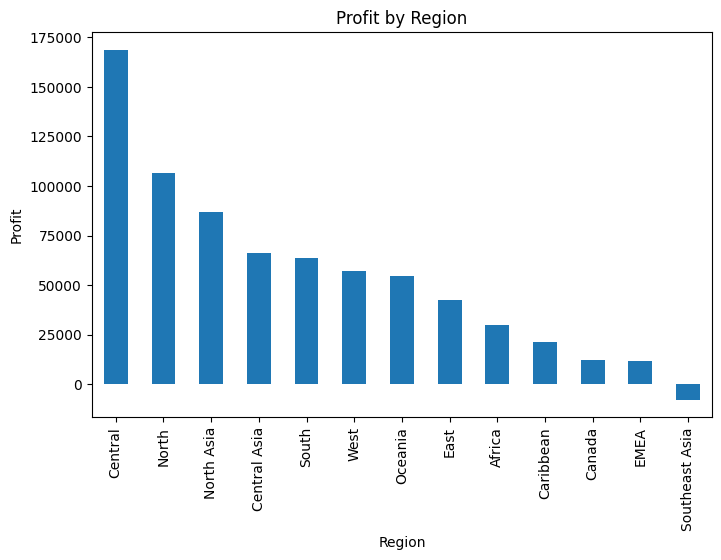


 SUMMARY 
Total Revenue : 7835128.0
Total Profit  : 714730.17

Top 10 Selling Products:
product_name
Eldon File Cart, Single Width                         31319.0
Rogers File Cart, Single Width                        22645.0
Tenex File Cart, Single Width                         20778.0
Smead File Cart, Single Width                         20775.0
Office Star Executive Leather Armchair, Adjustable    19355.0
Fellowes Lockers, Industrial                          19172.0
Smead Lockers, Industrial                             18648.0
Hewlett Copy Machine, Color                           16849.0
Rogers Lockers, Blue                                  16494.0
Fellowes Lockers, Wire Frame                          16470.0
Name: sales, dtype: float64

Profit by Category:
category
Office Supplies    350107.32450
Technology         267573.47238
Furniture           97049.37790
Name: profit, dtype: float64

Profit by Region:
region
Central           168764.86940
North             106622.10832
North A

In [2]:
# Task 5: Sales Data Analysis with Sales Dataset

import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("SuperStoreOrders.csv")

# Data Preprocessing
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Convert numeric columns
for col in ['sales', 'profit', 'discount', 'quantity']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove missing values
df.dropna(subset=['order_date', 'sales', 'profit'], inplace=True)

# Create Month-Year column
df['Month'] = df['order_date'].dt.to_period('M')


# 1. Monthly Revenue Trends
monthly_sales = df.groupby('Month')['sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index.astype(str),
         monthly_sales.values,
         marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# 2. Top Selling Products
top_products = (
    df.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Sales")
plt.xticks(rotation=75)
plt.show()


# 3. Profit Analysis by Category
category_profit = (
    df.groupby('category')['profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()


# 4. Profit Analysis by Region
region_profit = (
    df.groupby('region')['profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()


# Business Summary
print("\n SUMMARY ")

print("Total Revenue :", round(df['sales'].sum(), 2))
print("Total Profit  :", round(df['profit'].sum(), 2))

print("\nTop 10 Selling Products:")
print(top_products)

print("\nProfit by Category:")
print(category_profit)

print("\nProfit by Region:")
print(region_profit)
